# Modeling & Evaluation

### Library & Dependency

In [ ]:
import pickle
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.decomposition import PCA

from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

sns.set_style("whitegrid")

### Data Loader

In [45]:
with open("dataset/prepared_data.pkl", "rb") as f:
    data = pickle.load(f)

X_train = data["X_train"]
X_test = data["X_test"]
y_train = data["y_train"]
y_test = data["y_test"]

feature_names = data["feature_names"]

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

Training Shape : (455, 33)
Testing Shape  : (114, 33)


### Evaluation Functions

#### Metric evaluation

In [43]:
def evaluate_model(model, X_test, y_test):

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "AUROC": roc_auc_score(y_test, y_prob)
    }
    return results

In [37]:
def plot_confusion_matrix(model, X_test, y_test, title):

    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Benign","Malignant"],
        yticklabels=["Benign","Malignant"]
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)

    plt.show()

#### ROC Curve

In [38]:
def plot_roc(model, X_test, y_test, label):

    y_prob = model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    auc = roc_auc_score(y_test, y_prob)

    plt.plot(
        fpr,
        tpr,
        label=f"{label} (AUC={auc:.3f})"
    )

### Baseline Model

#### Logistic Regression

In [44]:
lr = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr.fit(X_train, y_train)

lr_results = evaluate_model(
    lr,
    X_test,
    y_test
)

pd.DataFrame([lr_results], index=["Logistic Regression"])

,Accuracy,Precision,Recall,F1 Score,AUROC
Logistic Regression,0.973684,0.97561,0.952381,0.963855,0.997024


#### KNN

In [46]:
knn = KNeighborsClassifier(
    n_neighbors=5,
    weights="distance"
)

knn.fit(X_train, y_train)

knn_results = evaluate_model(
    knn,
    X_test,
    y_test
)

pd.DataFrame([knn_results], index=["KNN"])

,Accuracy,Precision,Recall,F1 Score,AUROC
KNN,0.964912,1.0,0.904762,0.95,0.972222


#### Random Forest

In [47]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_results = evaluate_model(
    rf,
    X_test,
    y_test
)

pd.DataFrame([rf_results], index=["Random Forest"])

,Accuracy,Precision,Recall,F1 Score,AUROC
Random Forest,0.973684,1.0,0.928571,0.962963,0.996032


### Baseline Model Comparison

In [48]:
baseline_results = pd.DataFrame(
    [
        lr_results,
        knn_results,
        rf_results
    ],
    index=[
        "Logistic Regression",
        "KNN",
        "Random Forest"
    ]
)

baseline_results

,Accuracy,Precision,Recall,F1 Score,AUROC
Logistic Regression,0.973684,0.97561,0.952381,0.963855,0.997024
KNN,0.964912,1.00000,0.904762,0.950000,0.972222
Random Forest,0.973684,1.00000,0.928571,0.962963,0.996032


### Hyperparameter Optimization

#### Parameter Grid

In [51]:
rf_params = {
    "n_estimators":[100,200,300,500],
    "max_depth":[5,10,15,None],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4],
    "criterion":["gini","entropy"]
}

knn_params = {
    "n_neighbors": [3, 5, 7, 9, 11, 15],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan", "minkowski"]
}

#### Random Forest Search

In [53]:
rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    n_iter=20,
    cv=5,
    scoring="recall",
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

best_rf = rf_search.best_estimator_

#### KNN Search

In [52]:
knn_search = RandomizedSearchCV(
    KNeighborsClassifier(),
    knn_params,
    n_iter=15,
    cv=5,
    scoring="recall",
    random_state=42,
    n_jobs=-1
)

knn_search.fit(X_train, y_train)

best_knn = knn_search.best_estimator_

#### Best Parameters

In [54]:
print("Random Forest")
print(rf_search.best_params_)

print("\nKNN")
print(knn_search.best_params_)

Random Forest
{'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 15, 'criterion': 'gini'}

KNN
{'weights': 'uniform', 'n_neighbors': 3, 'metric': 'euclidean'}


### Tuned Model Comparison

In [55]:
best_rf_results = evaluate_model(
    best_rf,
    X_test,
    y_test
)

best_knn_results = evaluate_model(
    best_knn,
    X_test,
    y_test
)

tuned_results = pd.DataFrame(
    [
        best_rf_results,
        best_knn_results
    ],
    index=[
        "Tuned Random Forest",
        "Tuned KNN"
    ]
)

tuned_results

,Accuracy,Precision,Recall,F1 Score,AUROC
Tuned Random Forest,0.973684,1.0,0.928571,0.962963,0.996362
Tuned KNN,0.956140,1.0,0.880952,0.936709,0.973710


### PCA

#### PCA Transformation

In [56]:
pca = PCA(
    n_components=0.95,
    random_state=42
)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

#### PCA Summary

In [57]:
print(
    f"Original Features: {X_train.shape[1]}"
)

print(
    f"PCA Components: {X_train_pca.shape[1]}"
)

print(
    f"Explained Variance: "
    f"{np.sum(pca.explained_variance_ratio_):.4f}"
)

Original Features: 33
PCA Components: 11
Explained Variance: 0.9598


#### Scree Plot

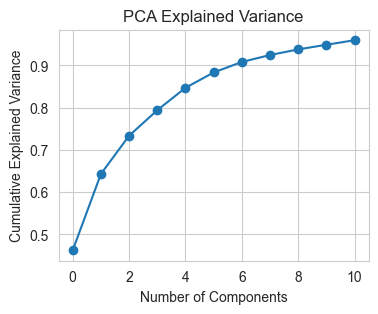

In [59]:
plt.figure(figsize=(4,3))

plt.plot(
    np.cumsum(
        pca.explained_variance_ratio_
    ),
    marker="o"
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")

plt.grid(True)

plt.show()

### PCA Models

#### Logistic Regression + PCA

In [64]:
lr_pca = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr_pca.fit(
    X_train_pca,
    y_train
)

lr_pca_results = evaluate_model(
    lr_pca,
    X_test_pca,
    y_test
)

#### KNN + PCA

In [65]:
knn_pca = KNeighborsClassifier(
    n_neighbors=5,
    weights="distance"
)

knn_pca.fit(
    X_train_pca,
    y_train
)

knn_pca_results = evaluate_model(
    knn_pca,
    X_test_pca,
    y_test
)

#### Random Forest + PCA

In [66]:
rf_pca = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_pca.fit(
    X_train_pca,
    y_train
)

rf_pca_results = evaluate_model(
    rf_pca,
    X_test_pca,
    y_test
)

### PCA Comparison

In [67]:
pca_results = pd.DataFrame(
    [
        lr_pca_results,
        knn_pca_results,
        rf_pca_results
    ],
    index=[
        "LR + PCA",
        "KNN + PCA",
        "RF + PCA"
    ]
)

pca_results

,Accuracy,Precision,Recall,F1 Score,AUROC
LR + PCA,0.982456,1.00,0.952381,0.975610,0.997685
KNN + PCA,0.956140,1.00,0.880952,0.936709,0.984127
RF + PCA,0.947368,0.95,0.904762,0.926829,0.993386


### ROC Curve Comparison

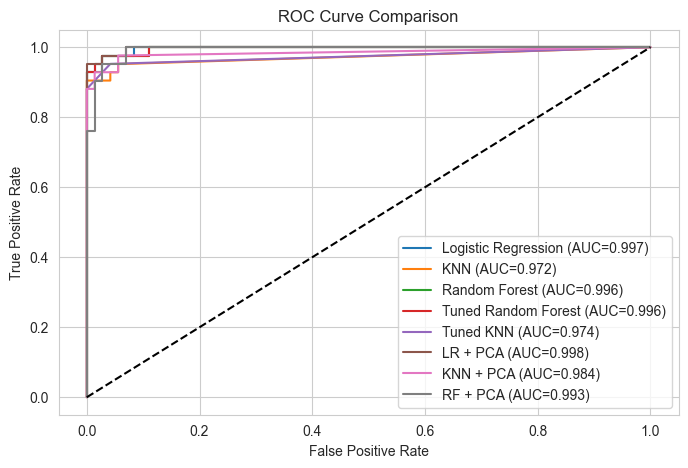

In [70]:
plt.figure(figsize=(8,5))

plot_roc(
    lr,
    X_test,
    y_test,
    "Logistic Regression"
)

plot_roc(
    knn,
    X_test,
    y_test,
    "KNN"
)

plot_roc(
    rf,
    X_test,
    y_test,
    "Random Forest"
)

plot_roc(
    best_rf,
    X_test,
    y_test,
    "Tuned Random Forest"
)

plot_roc(
    best_knn,
    X_test,
    y_test,
    "Tuned KNN"
)

plot_roc(
    lr_pca,
    X_test_pca,
    y_test,
    "LR + PCA"
)

plot_roc(
    knn_pca,
    X_test_pca,
    y_test,
    "KNN + PCA"
)

plot_roc(
    rf_pca,
    X_test_pca,
    y_test,
    "RF + PCA"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="black"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

### Feature Importance

In [77]:
importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(315)

,Feature,Importance
20,radius_worst,0.115889
22,perimeter_worst,0.106724
7,concave points_mean,0.099231
27,concave points_worst,0.087365
32,concavity_score,0.086138
23,area_worst,0.081272
2,perimeter_mean,0.051931
3,area_mean,0.043809
0,radius_mean,0.040869
31,radius_growth_ratio,0.036212


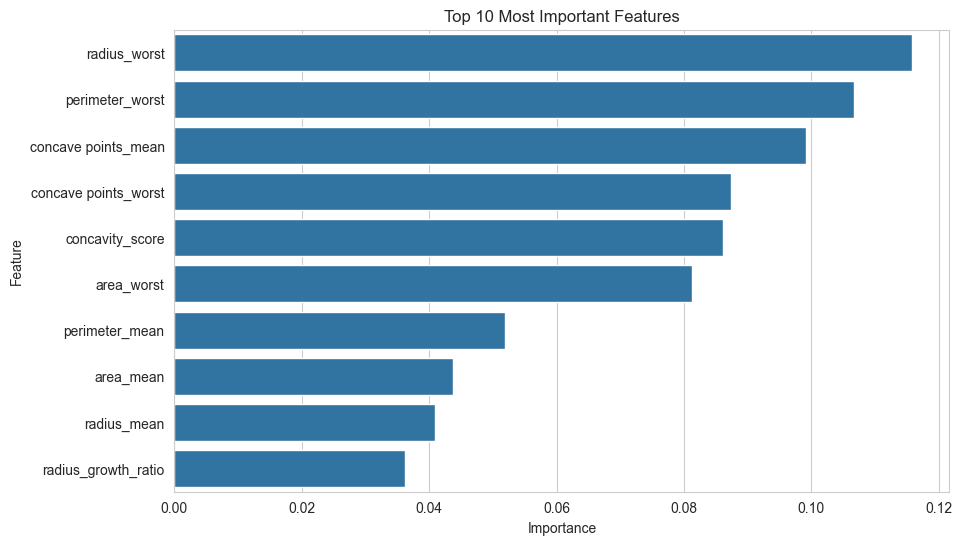

In [76]:
top_features = importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 10 Most Important Features"
)

plt.show()

### Final Result Table

In [80]:
final_results = pd.DataFrame(
    [
        lr_results,
        knn_results,
        rf_results,
        best_rf_results,
        best_knn_results,
        lr_pca_results,
        knn_pca_results,
        rf_pca_results
    ],
    index=[
        "Logistic Regression",
        "KNN",
        "Random Forest",
        "Tuned Random Forest",
        "Tuned KNN",
        "LR + PCA",
        "KNN + PCA",
        "RF + PCA"
    ]
)

final_results.sort_values(
    by="Recall",
    ascending=False
)

,Accuracy,Precision,Recall,F1 Score,AUROC
Logistic Regression,0.973684,0.97561,0.952381,0.963855,0.997024
LR + PCA,0.982456,1.00000,0.952381,0.975610,0.997685
Tuned Random Forest,0.973684,1.00000,0.928571,0.962963,0.996362
Random Forest,0.973684,1.00000,0.928571,0.962963,0.996032
KNN,0.964912,1.00000,0.904762,0.950000,0.972222
RF + PCA,0.947368,0.95000,0.904762,0.926829,0.993386
Tuned KNN,0.956140,1.00000,0.880952,0.936709,0.973710
KNN + PCA,0.956140,1.00000,0.880952,0.936709,0.984127


### Save Best Model

In [ ]:
selected_model = rf_pca
model_name = "RandomForestPCA"

with open(
    f"{model_name}.pkl",
    "wb"
) as f:
    pickle.dump(
        selected_model,
        f
    )

: 